# Calculate the PPE prior and constrained 90% prediction intervals for ∆(ln)LWP and ERFaci

#### Updated for resubmission using the Nephele reruns

* Calculate albedo susceptibility from PD LWP & relationship from Song et al. 2024, GRL
* Get dictionaries of constrained ensemble members
* Get unconstrained PPE statistics (range, 5th-95th percentiles)
* Get fit lines for (constrained) ∆LWP-LWP, ∆lnLWP-lnLWP, and ERFaci-∆LWP*da/dlwp

NOTE: PD hemispheric contrast in Nd was added initially (using MODIS data), but scrapped from paper; Nd output from the PPEs not directly comparable to Nd data from MODIS, so didn't make sense to do the comparison. All references to PD hemispheric ∆Nd should be ignored; ∆Nd constraint used in all analysis in the paper is the ∆(PD-PI) estimate from McCoy et al., 2020. 

In [1]:
import pickle

import xarray as xr
import numpy as np
import multi_ppe_constraint_rev as mpc
import matplotlib.pyplot as plt


In [2]:
main_path = "/glade/u/home/jnug/work/multi_PPE_data/"
file_path = main_path + "annual_means/"
pickle_path = main_path + "pickle_jar/"


In [3]:
ds_e3sm = xr.open_dataset(file_path + "E3SMv3_data_annual_means.nc")
ds_ga71 = xr.open_dataset(file_path + "GA7.1_data_annual_means.nc")
ds_cam6 = xr.open_dataset(file_path + "CAM6_data_annual_means.nc") 
ds_eham = xr.open_dataset(file_path + "ECHAM6-HAM_data_annual_means.nc")
ds_dict = {"E3SMv3": ds_e3sm, "GA7.1": ds_ga71, "CAM6": ds_cam6, "ECHAM6-HAM": ds_eham}


In [4]:
# # add hemispheric contrast

# for ppe, ds in ds_dict.items():
#     hem_nd = xr.open_dataset(file_path + f"{ppe}_PD_hemispheric_dNd_masked.nc")["delta_Nd_nhsh_masked"]
#     ds_dict[ppe]["delta_Nd_nhsh"] = hem_nd


In [5]:
# ONCE IT'S CALCULATED, add da/dlwp to the dictionary (see below)
try:
    with open(pickle_path + "PPE_dadlwp_dict.pickle", "rb") as handle:
        dadlwp_dict = pickle.load(handle)
        
    for ppe, ds in ds_dict.items():
        ds_dict[ppe]["dadlwp"] = dadlwp_dict[ppe]
except:
    print("da/dlwp dictionary for PPEs not created yet - do that first! (next group)")


In [6]:
# same for all
save = True
out_path = pickle_path


### Albedo susceptibility given PD LWP

0.06562158843739113 1.0760460556166351
0.06562158843739113 1.0760460556166351
0.06562158843739113 1.0760460556166351
0.06562158843739113 1.0760460556166351


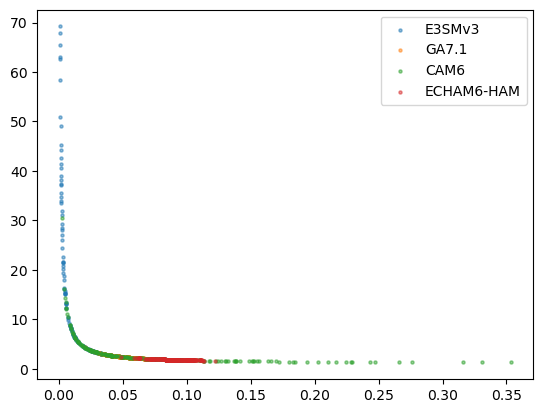

In [6]:
dadlwp_dict = {}

for ppe, ds in ds_dict.items():
    lwp = ds["LWP_pd_masked"]/1000.
    dadlwp = mpc.get_dadlwp(lwp)
    dadlwp_dict[ppe] = dadlwp

    plt.scatter(lwp, dadlwp, label=ppe, s=5, alpha=0.5)
plt.legend()
plt.show()

with open(pickle_path + "PPE_dadlwp_dict.pickle", "wb") as handle:
    pickle.dump(dadlwp_dict, handle)


In [7]:
# get CMIP6 values for *ALL* models - new for revisions

with open(file_path + "CMIP6_all_data_annual_means.pickle", "rb") as handle:
    cmip6_dict = pickle.load(handle)

dadlwp_cmip6_dict = {}
for model in list(cmip6_dict.keys()):
    lwp = cmip6_dict[model]["LWP_pd_masked"]/1000.
    dadlwp = mpc.get_dadlwp(lwp)
    dadlwp_cmip6_dict[model] = dadlwp

with open(file_path + "CMIP6_all_dadlwp_dict.pickle", "wb") as handle:
    pickle.dump(dadlwp_cmip6_dict, handle)


0.06562158843739113 1.0760460556166351
0.06562158843739113 1.0760460556166351
0.06562158843739113 1.0760460556166351
0.06562158843739113 1.0760460556166351
0.06562158843739113 1.0760460556166351
0.06562158843739113 1.0760460556166351
0.06562158843739113 1.0760460556166351
0.06562158843739113 1.0760460556166351
0.06562158843739113 1.0760460556166351
0.06562158843739113 1.0760460556166351
0.06562158843739113 1.0760460556166351
0.06562158843739113 1.0760460556166351
0.06562158843739113 1.0760460556166351
0.06562158843739113 1.0760460556166351
0.06562158843739113 1.0760460556166351


In [7]:
# quick check with Ci's values
# don't expect them to be the same (NH summer vs. global/annual) but should be close
cmip6_lwp_path = "/glade/u/home/cisong/test_codes/codes_figures/slopes/global_lwp_dlwp_15north_dadlwp0dot12/"
cmip6_ci_dict = {}
cmip6_plot_order = [
    "HadGEM3-GC31-LL",
    "MIROC6",
    "IPSL-CM6A-LR",
    "CNRM-CM6-1",
    "CESM2",
    "GFDL-CM4",
    "CNRM-ESM2-1",
    "CanESM5"
]
for model in cmip6_plot_order:
    data = dict(np.load(cmip6_lwp_path + "cmip6-{}.npz".format(model)))
    cmip6_ci_dict[model] = data
    

In [8]:
with open(file_path + "CMIP6_data_annual_means.pickle", "rb") as handle:
    cmip6_dict = pickle.load(handle)


In [9]:
dadlwp_cmip6_dict = {}
for model in list(cmip6_dict.keys()):
    lwp = cmip6_dict[model]["LWP_pd_masked"]/1000.
    dadlwp = mpc.get_dadlwp(lwp)
    dadlwp_cmip6_dict[model] = dadlwp

# with open(out_path + "CMIP6_dadlwp_dict.pickle", "wb") as handle:
#     pickle.dump(dadlwp_cmip6_dict, handle)
    

0.06562158843739113 1.0760460556166351
0.06562158843739113 1.0760460556166351
0.06562158843739113 1.0760460556166351
0.06562158843739113 1.0760460556166351
0.06562158843739113 1.0760460556166351
0.06562158843739113 1.0760460556166351
0.06562158843739113 1.0760460556166351
0.06562158843739113 1.0760460556166351
0.06562158843739113 1.0760460556166351


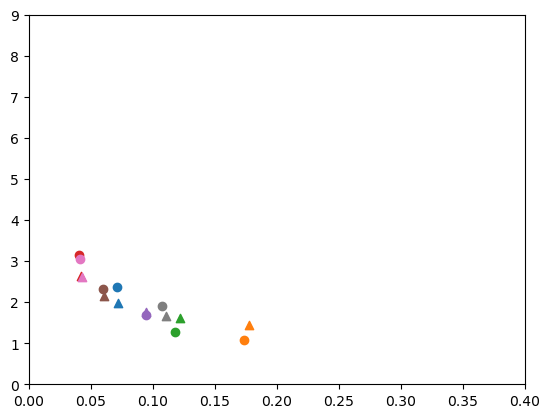

In [10]:
col_list = ["C{}".format(x) for x in np.arange(0, 10)]

for i, model in enumerate(cmip6_plot_order):
    plt.scatter(cmip6_dict[model]["LWP_pd_masked"]/1000., dadlwp_cmip6_dict[model], marker="^", label=model,
               color=col_list[i])
    plt.scatter(cmip6_ci_dict[model]["lwp"], cmip6_ci_dict[model]["dadlwp"], marker="o", label=model,
               color=col_list[i])

plt.xlim(0, .4)
plt.ylim(0, 9)
plt.show()


### Observational constraints
* strict (no tolerance)
* 5% tolerance
* 10%-50% tolerance

Ignore PD dNd hemispheric stuff (see note at top of notebook); not used in this study


In [7]:
ppe_constr_0_dict = {}
print("======== STRICT - 0% TOLERANCE ========\n")

for ppe, ds in ds_dict.items():
    ensn_dict = mpc.get_obs_constraints_tol(ds, ppe, err_tol=0, save=save, out_path=out_path)

    drop_dnd_pipd = len(ensn_dict["delta_Nd_pipd"]["cut"])/len(ds.member)*100.
    drop_dnd_hem = len(ensn_dict["delta_Nd_hem"]["cut"])/len(ds.member)*100.
    drop_dadlwp = len(ensn_dict["dadlwp"]["cut"])/len(ds.member)*100.
    drop_dlwp = len(ensn_dict["LWP_pd"]["cut"])/len(ds.member)*100.
    keep_all = len(ensn_dict["all"]["match"])/len(ds.member)*100.
    keep_all_hem = len(ensn_dict["all_ndhem"]["match"])/len(ds.member)*100.

    out_str = "{:.1f}% ({}) KEPT with hem, {:.1f}% ({}) with PD-PI;\n∆Nd (PD-PI) drops {:.1f}% ({}); ∆Nd (NH-SH) drops {:.1f}% ({});\nda/dlwp drops {:.1f}% ({}); PD LWP drops {:.1f}% ({})"
    
    print(ppe, out_str.format(keep_all_hem, len(ensn_dict["all_ndhem"]["match"]),
                              keep_all, len(ensn_dict["all"]["match"]),  
                              drop_dnd_pipd, len(ensn_dict["delta_Nd_pipd"]["cut"]),
                              drop_dnd_hem, len(ensn_dict["delta_Nd_hem"]["cut"]),
                              drop_dadlwp, len(ensn_dict["dadlwp"]["cut"]), 
                              drop_dlwp, len(ensn_dict["LWP_pd"]["cut"])))
    print("\n")
    ppe_constr_0_dict[ppe] = ensn_dict
    

======== STRICT - 0% TOLERANCE ========

E3SMv3 1.6% (4) KEPT with hem, 4.4% (11) with PD-PI;
∆Nd (PD-PI) drops 48.2% (121); ∆Nd (NH-SH) drops 89.2% (224);
da/dlwp drops 86.1% (216); PD LWP drops 92.0% (231)


GA7.1 0.5% (1) KEPT with hem, 3.3% (7) with PD-PI;
∆Nd (PD-PI) drops 61.6% (130); ∆Nd (NH-SH) drops 93.4% (197);
da/dlwp drops 82.5% (174); PD LWP drops 85.8% (181)


CAM6 1.4% (3) KEPT with hem, 4.1% (9) with PD-PI;
∆Nd (PD-PI) drops 26.7% (58); ∆Nd (NH-SH) drops 86.6% (188);
da/dlwp drops 72.4% (157); PD LWP drops 91.7% (199)


ECHAM6-HAM 0.9% (2) KEPT with hem, 6.8% (15) with PD-PI;
∆Nd (PD-PI) drops 64.3% (142); ∆Nd (NH-SH) drops 96.4% (213);
da/dlwp drops 13.6% (30); PD LWP drops 86.0% (190)




In [16]:
ppe_constr_05_dict = {}
print("======== 5% TOLERANCE ========\n")

for ppe, ds in ds_dict.items():
    ensn_dict = mpc.get_obs_constraints_tol(ds, ppe, err_tol=0.05, save=save, out_path=out_path)

    drop_dnd_pipd = len(ensn_dict["delta_Nd_pipd"]["cut"])/len(ds.member)*100.
    drop_dnd_hem = len(ensn_dict["delta_Nd_hem"]["cut"])/len(ds.member)*100.
    drop_dadlwp = len(ensn_dict["dadlwp"]["cut"])/len(ds.member)*100.
    drop_dlwp = len(ensn_dict["LWP_pd"]["cut"])/len(ds.member)*100.
    keep_all = len(ensn_dict["all"]["match"])/len(ds.member)*100.
    keep_all_hem = len(ensn_dict["all_ndhem"]["match"])/len(ds.member)*100.

    out_str = "{:.1f}% ({}) KEPT with hem, {:.1f}% ({}) with PD-PI;\n∆Nd (PD-PI) drops {:.1f}% ({}); ∆Nd (NH-SH) drops {:.1f}% ({});\nda/dlwp drops {:.1f}% ({}); PD LWP drops {:.1f}% ({})"
    
    print(ppe, out_str.format(keep_all_hem, len(ensn_dict["all_ndhem"]["match"]),
                              keep_all, len(ensn_dict["all"]["match"]),  
                              drop_dnd_pipd, len(ensn_dict["delta_Nd_pipd"]["cut"]),
                              drop_dnd_hem, len(ensn_dict["delta_Nd_hem"]["cut"]),
                              drop_dadlwp, len(ensn_dict["dadlwp"]["cut"]), 
                              drop_dlwp, len(ensn_dict["LWP_pd"]["cut"])))
    print("\n")
    ppe_constr_05_dict[ppe] = ensn_dict
    

======== 5% TOLERANCE ========

E3SMv3 2.0% (5) KEPT with hem, 7.6% (19) with PD-PI;
∆Nd (PD-PI) drops 45.4% (114); ∆Nd (NH-SH) drops 82.9% (208);
da/dlwp drops 80.1% (201); PD LWP drops 87.6% (220)


GA7.1 0.9% (2) KEPT with hem, 5.7% (12) with PD-PI;
∆Nd (PD-PI) drops 58.8% (124); ∆Nd (NH-SH) drops 91.5% (193);
da/dlwp drops 69.2% (146); PD LWP drops 79.6% (168)


CAM6 3.7% (8) KEPT with hem, 8.3% (18) with PD-PI;
∆Nd (PD-PI) drops 24.0% (52); ∆Nd (NH-SH) drops 75.1% (163);
da/dlwp drops 64.1% (139); PD LWP drops 86.6% (188)


ECHAM6-HAM 2.3% (5) KEPT with hem, 14.5% (32) with PD-PI;
∆Nd (PD-PI) drops 61.5% (136); ∆Nd (NH-SH) drops 94.6% (209);
da/dlwp drops 0.9% (2); PD LWP drops 72.4% (160)




In [17]:
ppe_constr_10_dict = {}
print("======== 10% TOLERANCE ========\n")

for ppe, ds in ds_dict.items():
    ensn_dict = mpc.get_obs_constraints_tol(ds, ppe, err_tol=0.1, save=save, out_path=out_path)

    drop_dnd_pipd = len(ensn_dict["delta_Nd_pipd"]["cut"])/len(ds.member)*100.
    drop_dnd_hem = len(ensn_dict["delta_Nd_hem"]["cut"])/len(ds.member)*100.
    drop_dadlwp = len(ensn_dict["dadlwp"]["cut"])/len(ds.member)*100.
    drop_dlwp = len(ensn_dict["LWP_pd"]["cut"])/len(ds.member)*100.
    keep_all = len(ensn_dict["all"]["match"])/len(ds.member)*100.
    keep_all_hem = len(ensn_dict["all_ndhem"]["match"])/len(ds.member)*100.

    out_str = "{:.1f}% ({}) KEPT with hem, {:.1f}% ({}) with PD-PI;\n∆Nd (PD-PI) drops {:.1f}% ({}); ∆Nd (NH-SH) drops {:.1f}% ({});\nda/dlwp drops {:.1f}% ({}); PD LWP drops {:.1f}% ({})"
    
    print(ppe, out_str.format(keep_all_hem, len(ensn_dict["all_ndhem"]["match"]),
                              keep_all, len(ensn_dict["all"]["match"]),  
                              drop_dnd_pipd, len(ensn_dict["delta_Nd_pipd"]["cut"]),
                              drop_dnd_hem, len(ensn_dict["delta_Nd_hem"]["cut"]),
                              drop_dadlwp, len(ensn_dict["dadlwp"]["cut"]), 
                              drop_dlwp, len(ensn_dict["LWP_pd"]["cut"])))
    print("\n")
    ppe_constr_10_dict[ppe] = ensn_dict
    

======== 10% TOLERANCE ========

E3SMv3 5.2% (13) KEPT with hem, 11.2% (28) with PD-PI;
∆Nd (PD-PI) drops 41.4% (104); ∆Nd (NH-SH) drops 72.9% (183);
da/dlwp drops 74.9% (188); PD LWP drops 83.3% (209)


GA7.1 3.3% (7) KEPT with hem, 10.0% (21) with PD-PI;
∆Nd (PD-PI) drops 55.0% (116); ∆Nd (NH-SH) drops 86.3% (182);
da/dlwp drops 53.1% (112); PD LWP drops 71.1% (150)


CAM6 5.5% (12) KEPT with hem, 12.0% (26) with PD-PI;
∆Nd (PD-PI) drops 22.1% (48); ∆Nd (NH-SH) drops 67.3% (146);
da/dlwp drops 56.2% (122); PD LWP drops 83.4% (181)


ECHAM6-HAM 4.5% (10) KEPT with hem, 22.2% (49) with PD-PI;
∆Nd (PD-PI) drops 56.6% (125); ∆Nd (NH-SH) drops 93.2% (206);
da/dlwp drops 0.5% (1); PD LWP drops 50.2% (111)




In [18]:
ppe_constr_20_dict = {}
print("======== 20% TOLERANCE ========\n")

for ppe, ds in ds_dict.items():
    ensn_dict = mpc.get_obs_constraints_tol(ds, ppe, err_tol=0.2, save=save, out_path=out_path)

    drop_dnd_pipd = len(ensn_dict["delta_Nd_pipd"]["cut"])/len(ds.member)*100.
    drop_dnd_hem = len(ensn_dict["delta_Nd_hem"]["cut"])/len(ds.member)*100.
    drop_dadlwp = len(ensn_dict["dadlwp"]["cut"])/len(ds.member)*100.
    drop_dlwp = len(ensn_dict["LWP_pd"]["cut"])/len(ds.member)*100.
    keep_all = len(ensn_dict["all"]["match"])/len(ds.member)*100.
    keep_all_hem = len(ensn_dict["all_ndhem"]["match"])/len(ds.member)*100.

    out_str = "{:.1f}% ({}) KEPT with hem, {:.1f}% ({}) with PD-PI;\n∆Nd (PD-PI) drops {:.1f}% ({}); ∆Nd (NH-SH) drops {:.1f}% ({});\nda/dlwp drops {:.1f}% ({}); PD LWP drops {:.1f}% ({})"
    
    print(ppe, out_str.format(keep_all_hem, len(ensn_dict["all_ndhem"]["match"]),
                              keep_all, len(ensn_dict["all"]["match"]),  
                              drop_dnd_pipd, len(ensn_dict["delta_Nd_pipd"]["cut"]),
                              drop_dnd_hem, len(ensn_dict["delta_Nd_hem"]["cut"]),
                              drop_dadlwp, len(ensn_dict["dadlwp"]["cut"]), 
                              drop_dlwp, len(ensn_dict["LWP_pd"]["cut"])))
    print("\n")
    ppe_constr_20_dict[ppe] = ensn_dict
    

======== 20% TOLERANCE ========

E3SMv3 10.0% (25) KEPT with hem, 20.7% (52) with PD-PI;
∆Nd (PD-PI) drops 33.1% (83); ∆Nd (NH-SH) drops 62.2% (156);
da/dlwp drops 67.3% (169); PD LWP drops 74.5% (187)


GA7.1 7.6% (16) KEPT with hem, 22.3% (47) with PD-PI;
∆Nd (PD-PI) drops 48.8% (103); ∆Nd (NH-SH) drops 82.5% (174);
da/dlwp drops 34.6% (73); PD LWP drops 50.7% (107)


CAM6 13.4% (29) KEPT with hem, 22.6% (49) with PD-PI;
∆Nd (PD-PI) drops 18.4% (40); ∆Nd (NH-SH) drops 51.6% (112);
da/dlwp drops 41.0% (89); PD LWP drops 71.9% (156)


ECHAM6-HAM 9.5% (21) KEPT with hem, 33.9% (75) with PD-PI;
∆Nd (PD-PI) drops 50.2% (111); ∆Nd (NH-SH) drops 87.8% (194);
da/dlwp drops 0.0% (0); PD LWP drops 29.9% (66)




In [19]:
ppe_constr_30_dict = {}
print("======== 30% TOLERANCE ========\n")

for ppe, ds in ds_dict.items():
    ensn_dict = mpc.get_obs_constraints_tol(ds, ppe, err_tol=0.3, save=save, out_path=out_path)

    drop_dnd_pipd = len(ensn_dict["delta_Nd_pipd"]["cut"])/len(ds.member)*100.
    drop_dnd_hem = len(ensn_dict["delta_Nd_hem"]["cut"])/len(ds.member)*100.
    drop_dadlwp = len(ensn_dict["dadlwp"]["cut"])/len(ds.member)*100.
    drop_dlwp = len(ensn_dict["LWP_pd"]["cut"])/len(ds.member)*100.
    keep_all = len(ensn_dict["all"]["match"])/len(ds.member)*100.
    keep_all_hem = len(ensn_dict["all_ndhem"]["match"])/len(ds.member)*100.

    out_str = "{:.1f}% ({}) KEPT with hem, {:.1f}% ({}) with PD-PI;\n∆Nd (PD-PI) drops {:.1f}% ({}); ∆Nd (NH-SH) drops {:.1f}% ({});\nda/dlwp drops {:.1f}% ({}); PD LWP drops {:.1f}% ({})"
    
    print(ppe, out_str.format(keep_all_hem, len(ensn_dict["all_ndhem"]["match"]),
                              keep_all, len(ensn_dict["all"]["match"]),  
                              drop_dnd_pipd, len(ensn_dict["delta_Nd_pipd"]["cut"]),
                              drop_dnd_hem, len(ensn_dict["delta_Nd_hem"]["cut"]),
                              drop_dadlwp, len(ensn_dict["dadlwp"]["cut"]), 
                              drop_dlwp, len(ensn_dict["LWP_pd"]["cut"])))
    print("\n")
    ppe_constr_30_dict[ppe] = ensn_dict
    

======== 30% TOLERANCE ========

E3SMv3 17.5% (44) KEPT with hem, 29.1% (73) with PD-PI;
∆Nd (PD-PI) drops 27.5% (69); ∆Nd (NH-SH) drops 55.0% (138);
da/dlwp drops 61.4% (154); PD LWP drops 67.3% (169)


GA7.1 14.7% (31) KEPT with hem, 35.1% (74) with PD-PI;
∆Nd (PD-PI) drops 43.1% (91); ∆Nd (NH-SH) drops 74.9% (158);
da/dlwp drops 17.5% (37); PD LWP drops 35.1% (74)


CAM6 23.5% (51) KEPT with hem, 31.8% (69) with PD-PI;
∆Nd (PD-PI) drops 15.7% (34); ∆Nd (NH-SH) drops 39.6% (86);
da/dlwp drops 31.3% (68); PD LWP drops 62.2% (135)


ECHAM6-HAM 18.1% (40) KEPT with hem, 48.4% (107) with PD-PI;
∆Nd (PD-PI) drops 44.8% (99); ∆Nd (NH-SH) drops 81.0% (179);
da/dlwp drops 0.0% (0); PD LWP drops 11.8% (26)




In [20]:
ppe_constr_50_dict = {}
print("======== 50% TOLERANCE ========\n")

for ppe, ds in ds_dict.items():
    ensn_dict = mpc.get_obs_constraints_tol(ds, ppe, err_tol=0.5, save=save, out_path=out_path)

    drop_dnd_pipd = len(ensn_dict["delta_Nd_pipd"]["cut"])/len(ds.member)*100.
    drop_dnd_hem = len(ensn_dict["delta_Nd_hem"]["cut"])/len(ds.member)*100.
    drop_dadlwp = len(ensn_dict["dadlwp"]["cut"])/len(ds.member)*100.
    drop_dlwp = len(ensn_dict["LWP_pd"]["cut"])/len(ds.member)*100.
    keep_all = len(ensn_dict["all"]["match"])/len(ds.member)*100.
    keep_all_hem = len(ensn_dict["all_ndhem"]["match"])/len(ds.member)*100.

    out_str = "{:.1f}% ({}) KEPT with hem, {:.1f}% ({}) with PD-PI;\n∆Nd (PD-PI) drops {:.1f}% ({}); ∆Nd (NH-SH) drops {:.1f}% ({});\nda/dlwp drops {:.1f}% ({}); PD LWP drops {:.1f}% ({})"
    
    print(ppe, out_str.format(keep_all_hem, len(ensn_dict["all_ndhem"]["match"]),
                              keep_all, len(ensn_dict["all"]["match"]),  
                              drop_dnd_pipd, len(ensn_dict["delta_Nd_pipd"]["cut"]),
                              drop_dnd_hem, len(ensn_dict["delta_Nd_hem"]["cut"]),
                              drop_dadlwp, len(ensn_dict["dadlwp"]["cut"]), 
                              drop_dlwp, len(ensn_dict["LWP_pd"]["cut"])))
    print("\n")
    ppe_constr_50_dict[ppe] = ensn_dict
    

======== 50% TOLERANCE ========

E3SMv3 40.6% (102) KEPT with hem, 45.8% (115) with PD-PI;
∆Nd (PD-PI) drops 18.7% (47); ∆Nd (NH-SH) drops 31.5% (79);
da/dlwp drops 49.4% (124); PD LWP drops 50.6% (127)


GA7.1 35.1% (74) KEPT with hem, 62.1% (131) with PD-PI;
∆Nd (PD-PI) drops 32.7% (69); ∆Nd (NH-SH) drops 63.5% (134);
da/dlwp drops 4.7% (10); PD LWP drops 5.2% (11)


CAM6 47.9% (104) KEPT with hem, 53.9% (117) with PD-PI;
∆Nd (PD-PI) drops 6.9% (15); ∆Nd (NH-SH) drops 18.0% (39);
da/dlwp drops 25.8% (56); PD LWP drops 43.3% (94)


ECHAM6-HAM 29.9% (66) KEPT with hem, 74.7% (165) with PD-PI;
∆Nd (PD-PI) drops 24.9% (55); ∆Nd (NH-SH) drops 70.1% (155);
da/dlwp drops 0.0% (0); PD LWP drops 0.5% (1)




#### Get & save unconstrained ranges 

In [33]:
uc_ranges_dict = {}

for ppe, ds in ds_dict.items():
    test_dict = mpc.read_obs_constraints(ppe, out_path=out_path, extra="_error_tol_0.05")
    ds_good = ds.sel(member=test_dict["all"]["match"])

    # conv + land masked for PD LWP
    lwp_pd_uc = ds["LWP_pd_masked"].min().values, ds["LWP_pd_masked"].max().values
    lnlwp_pd_uc = np.log(ds["LWP_pd_masked"]).min().values, np.log(ds["LWP_pd_masked"]).max().values

    # global values for the rest
    dlwp_uc = ds["delta_LWP"].min().values, ds["delta_LWP"].max().values
    dlnlwp_uc = (np.log(ds["LWP_pd"]) - np.log(ds["LWP_pi"])).min().values, (np.log(ds["LWP_pd"]) - np.log(ds["LWP_pi"])).max().values
    erfaci_uc = ds["ERFaci"].min().values, ds["ERFaci"].max().values
    dlwp_dadlwp_uc = (ds["delta_LWP"]/1000.*ds["dadlwp"]).min().values, (ds["delta_LWP"]/1000.*ds["dadlwp"]).max().values

    uc_range_dict = {
        "LWP_pd_masked": lwp_pd_uc,
        "lnLWP_pd_masked": lnlwp_pd_uc,
        "delta_LWP": dlwp_uc,
        "delta_lnLWP": dlnlwp_uc,
        "ERFaci": erfaci_uc,
        "dlwp_dadlwp": dlwp_dadlwp_uc
    }

    uc_ranges_dict[ppe] = uc_range_dict

with open(out_path + "PPE_unconstrained_min_max.pickle", "wb") as handle:
    pickle.dump(uc_ranges_dict, handle)


#### Get & save 5th and 95th unconstrained percentiles

In [35]:
uc_595_dict = {}

for ppe, ds in ds_dict.items():
    # conv + land masked for PD LWP
    lwp_pd_uc = ds["LWP_pd_masked"].quantile(0.05).values, ds["LWP_pd_masked"].quantile(0.95).values
    lnlwp_pd_uc = np.log(ds["LWP_pd_masked"]).quantile(0.05).values, np.log(ds["LWP_pd_masked"]).quantile(0.95).values

    # global for the rest
    dlwp_uc = ds["delta_LWP"].quantile(0.05).values, ds["delta_LWP"].quantile(0.95).values
    dlnlwp_uc = (np.log(ds["LWP_pd"]) - np.log(ds["LWP_pi"])).quantile(0.05).values, (np.log(ds["LWP_pd"]) - np.log(ds["LWP_pi"])).quantile(0.95).values
    erfaci_uc = ds["ERFaci"].quantile(0.05).values, ds["ERFaci"].quantile(0.95).values
    dlwp_dadlwp_uc = (ds["delta_LWP"]/1000.*ds["dadlwp"]).quantile(0.05).values, (ds["delta_LWP"]/1000.*ds["dadlwp"]).quantile(0.95).values

    uc_dict = {
        "LWP_pd_masked": lwp_pd_uc,
        "lnLWP_pd_masked": lnlwp_pd_uc,
        "delta_LWP": dlwp_uc,
        "delta_lnLWP": dlnlwp_uc,
        "ERFaci": erfaci_uc,
        "dlwp_dadlwp": dlwp_dadlwp_uc
    }

    uc_595_dict[ppe] = uc_dict

with open(out_path + "PPE_unconstrained_5th_95th_pctl.pickle", "wb") as handle:
    pickle.dump(uc_595_dict, handle)



### Fit lines 
Using 5/5/30 constraints

#### ∆LWP-LWP (linear)

In [45]:
import importlib
importlib.reload(mpc)

<module 'multi_ppe_constraint_rev' from '/glade/work/jnug/codes/e3sm-ppe-aci/analysis/notebooks/multi_PPE_adj/revisions/multi_ppe_constraint_rev.py'>

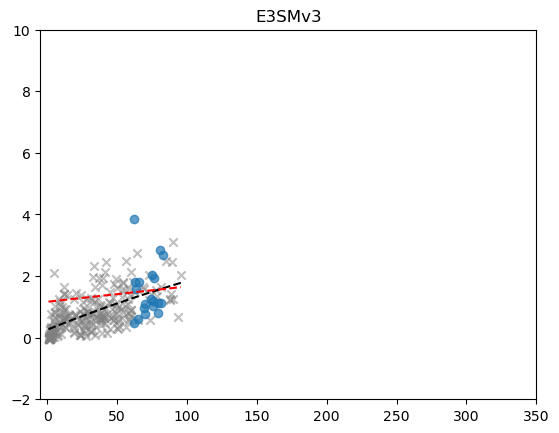

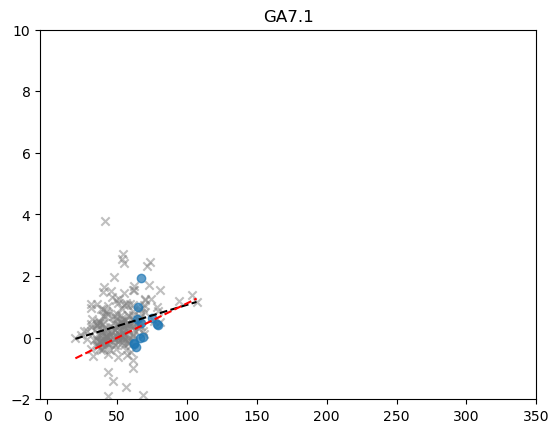

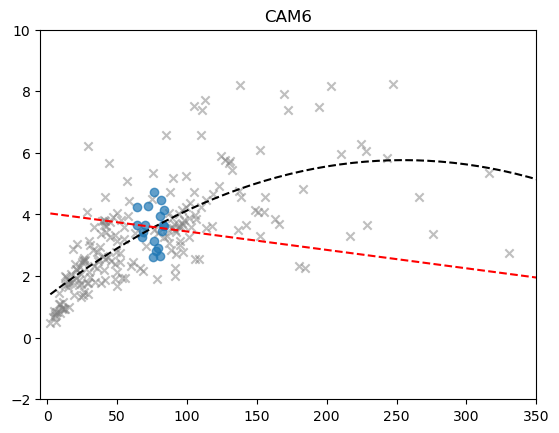

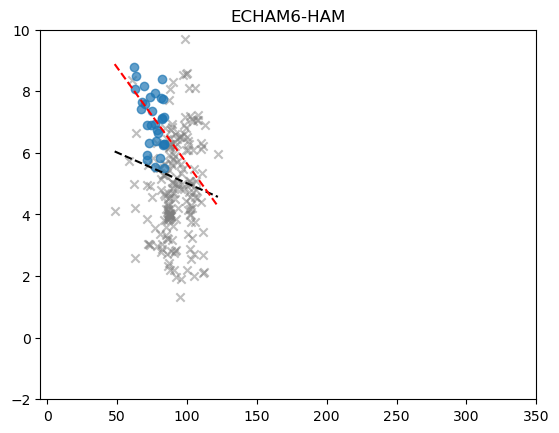

In [12]:
for ppe, ds in ds_dict.items():
    if ppe == "CAM6" or ppe == "E3SMv3":
        degree = 2
    else:
        degree = 1

    with open(pickle_path + f"{ppe}_constrained_members_dict_error_tol_0.05.pickle", "rb") as handle:
        err05_dict = pickle.load(handle)
        
    with open(pickle_path + f"{ppe}_constrained_members_dict_error_tol_0.3.pickle", "rb") as handle:
        err30_dict = pickle.load(handle)

    dadlwp_meet = err05_dict["dadlwp"]["match"]
    lwp_meet = err05_dict["LWP_pd"]["match"]
    dnd_meet = err05_dict["delta_Nd_pipd"]["match"]

    ensn_constr_all = [x for x in dnd_meet if (x in dadlwp_meet and x in lwp_meet)]
    ensn_cut = [x for x in ds.member.values if x not in ensn_constr_all]

    
    ds_constr = ds.sel(member=ensn_constr_all)
    xc = ds_constr["LWP_pd_masked"]
    yc = ds_constr["delta_LWP"]
    x = ds["LWP_pd_masked"]
    y = ds["delta_LWP"]
    coeffs_dlwp_lwp_constr = mpc.get_fit_line(ppe, xc, yc, degree=1, save=True, varname="dLWP_LWP_constr_Ndpipd", 
                                         out_path=out_path)
    coeffs_dlwp_lwp = mpc.get_fit_line(ppe, x, y, degree=degree, save=True, varname="dLWP_LWP_prior_Ndpipd", 
                                         out_path=out_path)
    
    xnc = ds["LWP_pd_masked"].sel(member=ensn_cut)
    ync = ds["delta_LWP"].sel(member=ensn_cut)

    fig, ax = plt.subplots()
    ax.scatter(xnc, ync, color="grey", marker="x", alpha=0.5)
    ax.scatter(xc, yc, alpha=0.7)
    xspan = np.linspace(x.min(), x.max(), 40)
    if len(coeffs_dlwp_lwp_constr) == 2:
        yfit = mpc.linear(xspan, coeffs_dlwp_lwp_constr)
    else:
        yfit = mpc.quadratic(xspan, coeffs_dlwp_lwp_constr)
    if len(coeffs_dlwp_lwp) == 2:
        yfit_prior = mpc.linear(xspan, coeffs_dlwp_lwp)
    else:
        yfit_prior = mpc.quadratic(xspan, coeffs_dlwp_lwp)
        
    ax.plot(xspan, yfit_prior, color="k", linestyle="--")
    ax.plot(xspan, yfit, color="r", linestyle="--")
    ax.set_title(ppe)
    ax.set_xlim(-5, 350)
    ax.set_ylim(-2, 10)
    plt.show()


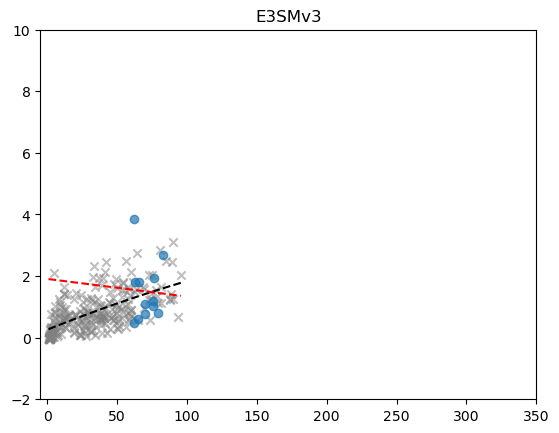

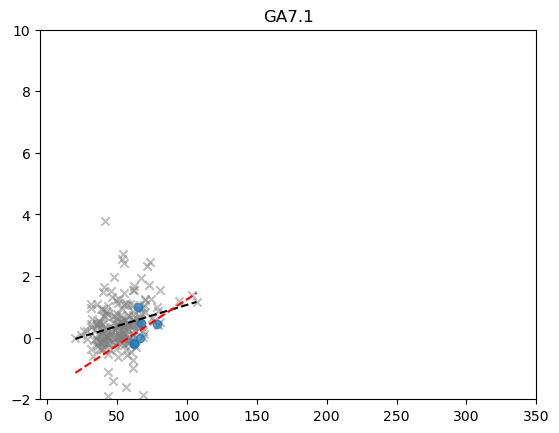

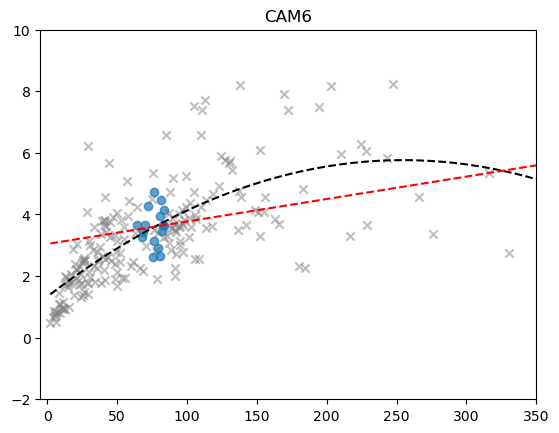

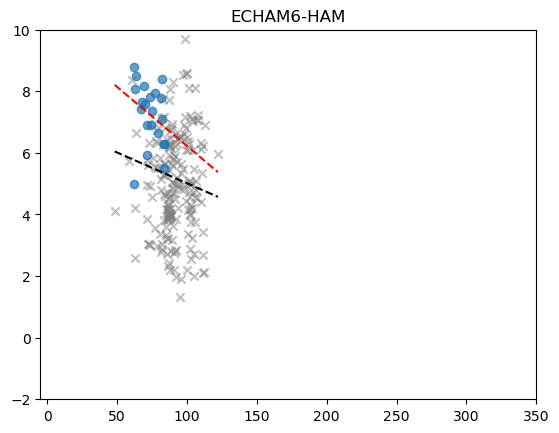

In [54]:
for ppe, ds in ds_dict.items():
    if ppe == "CAM6" or ppe == "E3SMv3":
        degree = 2
    else:
        degree = 1

    with open(pickle_path + f"{ppe}_constrained_members_dict_error_tol_0.05.pickle", "rb") as handle:
        err05_dict = pickle.load(handle)
        
    with open(pickle_path + f"{ppe}_constrained_members_dict_error_tol_0.3.pickle", "rb") as handle:
        err30_dict = pickle.load(handle)

    dadlwp_meet = err05_dict["dadlwp"]["match"]
    lwp_meet = err05_dict["LWP_pd"]["match"]
    dnd_meet = err30_dict["delta_Nd_hem"]["match"]

    ensn_constr_all = [x for x in dnd_meet if (x in dadlwp_meet and x in lwp_meet)]
    ensn_cut = [x for x in ds.member.values if x not in ensn_constr_all]

    
    ds_constr = ds.sel(member=ensn_constr_all)
    xc = ds_constr["LWP_pd_masked"]
    yc = ds_constr["delta_LWP"]
    x = ds["LWP_pd_masked"]
    y = ds["delta_LWP"]
    coeffs_dlwp_lwp_constr = mpc.get_fit_line(ppe, xc, yc, degree=1, save=True, varname="dLWP_LWP_constr", 
                                         out_path=out_path)
    coeffs_dlwp_lwp = mpc.get_fit_line(ppe, x, y, degree=degree, save=True, varname="dLWP_LWP_prior", 
                                         out_path=out_path)
    
    xnc = ds["LWP_pd_masked"].sel(member=ensn_cut)
    ync = ds["delta_LWP"].sel(member=ensn_cut)

    fig, ax = plt.subplots()
    ax.scatter(xnc, ync, color="grey", marker="x", alpha=0.5)
    ax.scatter(xc, yc, alpha=0.7)
    xspan = np.linspace(x.min(), x.max(), 40)
    if len(coeffs_dlwp_lwp_constr) == 2:
        yfit = mpc.linear(xspan, coeffs_dlwp_lwp_constr)
    else:
        yfit = mpc.quadratic(xspan, coeffs_dlwp_lwp_constr)
    if len(coeffs_dlwp_lwp) == 2:
        yfit_prior = mpc.linear(xspan, coeffs_dlwp_lwp)
    else:
        yfit_prior = mpc.quadratic(xspan, coeffs_dlwp_lwp)
        
    ax.plot(xspan, yfit_prior, color="k", linestyle="--")
    ax.plot(xspan, yfit, color="r", linestyle="--")
    ax.set_title(ppe)
    ax.set_xlim(-5, 350)
    ax.set_ylim(-2, 10)
    plt.show()


#### ∆LWP-LWP (log space)

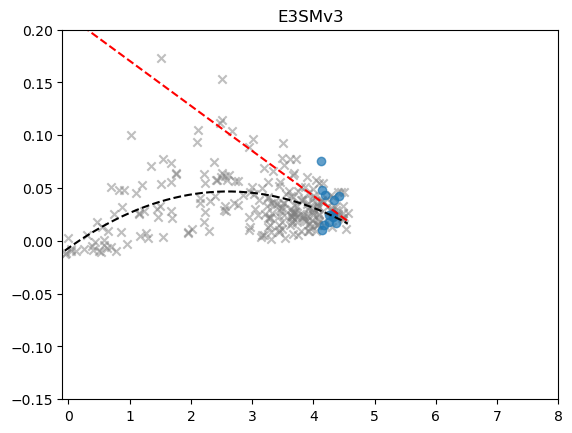

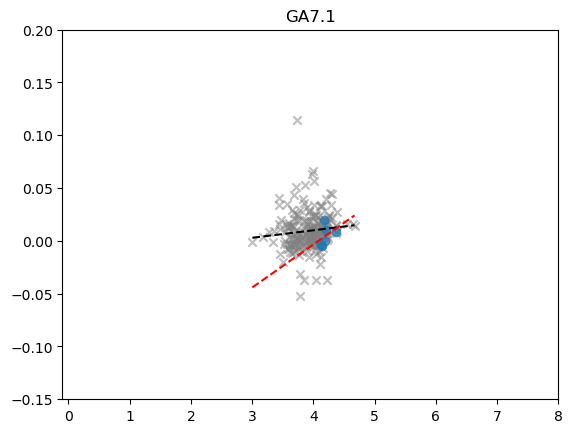

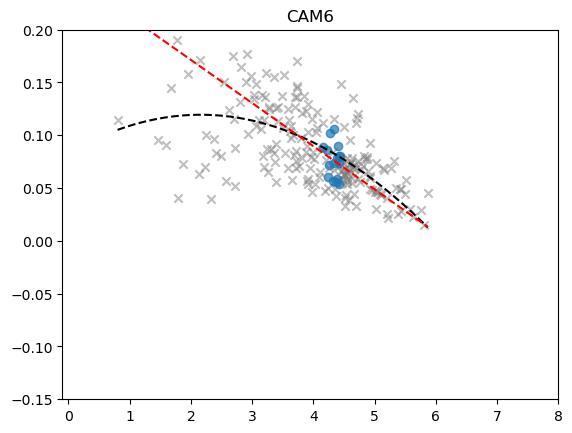

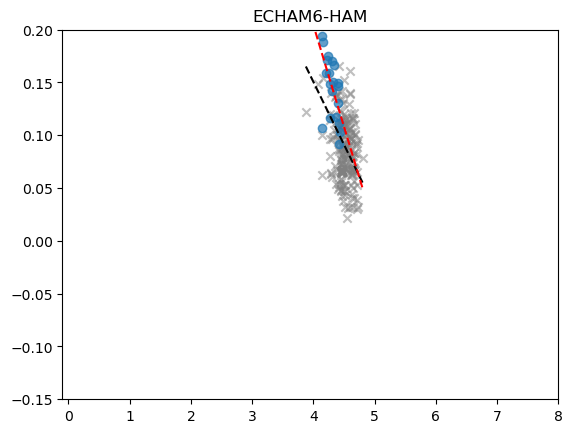

In [56]:
for ppe, ds in ds_dict.items():
    if ppe == "CAM6" or ppe == "E3SMv3":
        degree = 2
    else:
        degree = 1
        
    with open(pickle_path + f"{ppe}_constrained_members_dict_error_tol_0.05.pickle", "rb") as handle:
        err05_dict = pickle.load(handle)
        
    with open(pickle_path + f"{ppe}_constrained_members_dict_error_tol_0.3.pickle", "rb") as handle:
        err30_dict = pickle.load(handle)

    dadlwp_meet = err05_dict["dadlwp"]["match"]
    lwp_meet = err05_dict["LWP_pd"]["match"]
    dnd_meet = err30_dict["delta_Nd_hem"]["match"]

    ensn_constr_all = [x for x in dnd_meet if (x in dadlwp_meet and x in lwp_meet)]
    ensn_cut = [x for x in ds.member.values if x not in ensn_constr_all]
    
    ds_constr = ds.sel(member=ensn_constr_all)
    xc = np.log(ds_constr["LWP_pd_masked"])
    yc = np.log(ds_constr["LWP_pd"]) - np.log(ds_constr["LWP_pi"])
    x = np.log(ds["LWP_pd_masked"])
    y = np.log(ds["LWP_pd"]) - np.log(ds["LWP_pi"])

    coeffs_dlnlwp_lwp = mpc.get_fit_line(ppe, xc, yc, degree=1, save=True, varname="dlnLWP_lnLWP_constr", 
                                         out_path=out_path)
    coeffs_dlnlwp_lwp_prior = mpc.get_fit_line(ppe, x, y, degree=degree, save=True, varname="dlnLWP_lnLWP_prior", 
                                         out_path=out_path)
    
    xnc = np.log(ds["LWP_pd_masked"].sel(member=ensn_cut))
    ync = np.log(ds["LWP_pd"].sel(member=ensn_cut)) - np.log(ds["LWP_pi"].sel(member=ensn_cut))

    fig, ax = plt.subplots()
    ax.scatter(xnc, ync, color="grey", marker="x", alpha=0.5)
    ax.scatter(xc, yc, alpha=0.7)
    xspan = np.linspace(x.min(), x.max(), 40)
    if len(coeffs_dlnlwp_lwp) == 2:
        yfit = mpc.linear(xspan, coeffs_dlnlwp_lwp)
    else:
        yfit = mpc.quadratic(xspan, coeffs_dlnlwp_lwp)
    if len(coeffs_dlnlwp_lwp_prior) == 2:
        yfit_prior = mpc.linear(xspan, coeffs_dlnlwp_lwp_prior)
    else:
        yfit_prior = mpc.quadratic(xspan, coeffs_dlnlwp_lwp_prior)

    ax.plot(xspan, yfit_prior, color="k", linestyle="--")
    ax.plot(xspan, yfit, color="r", linestyle="--")
    ax.set_title(ppe)
    ax.set_xlim(-0.1, 8)
    ax.set_ylim(-0.15, 0.20)
    plt.show()


#### ERFaci-∆LWP

E3SMv3: r2 = 0.733


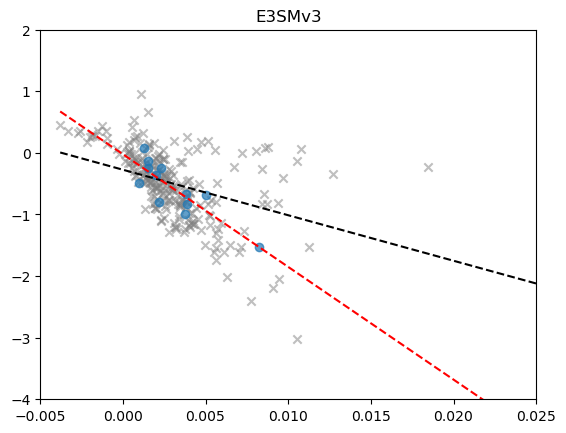

GA7.1: r2 = 0.833


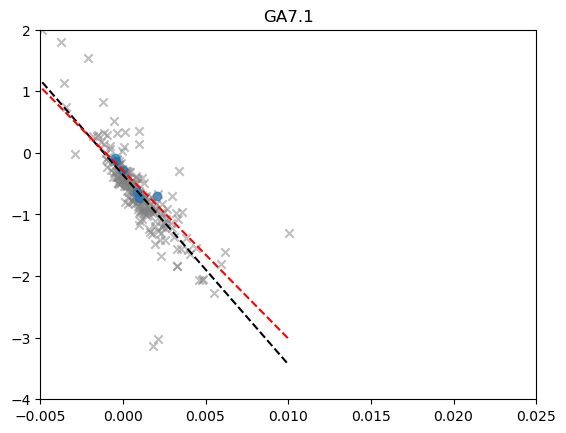

CAM6: r2 = 0.373


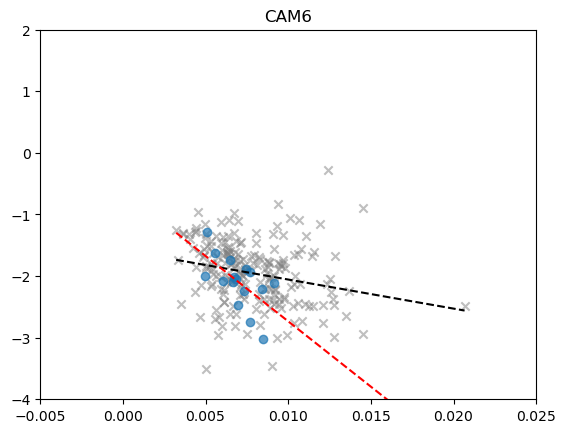

ECHAM6-HAM: r2 = 0.846


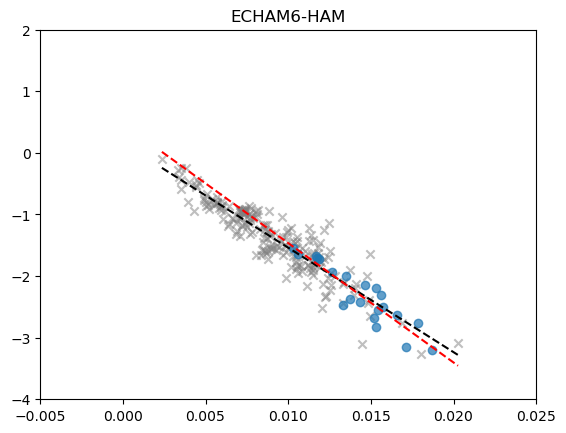

In [57]:
for ppe, ds in ds_dict.items():
    if ppe == "CAM6" or ppe == "E3SMv3":
        degree = 1
    else:
        degree = 1
        
        
    with open(pickle_path + f"{ppe}_constrained_members_dict_error_tol_0.05.pickle", "rb") as handle:
        err05_dict = pickle.load(handle)
        
    with open(pickle_path + f"{ppe}_constrained_members_dict_error_tol_0.3.pickle", "rb") as handle:
        err30_dict = pickle.load(handle)

    dadlwp_meet = err05_dict["dadlwp"]["match"]
    lwp_meet = err05_dict["LWP_pd"]["match"]
    dnd_meet = err30_dict["delta_Nd_hem"]["match"]

    ensn_constr_all = [x for x in dnd_meet if (x in dadlwp_meet and x in lwp_meet)]
    ensn_cut = [x for x in ds.member.values if x not in ensn_constr_all]
    
    ds_constr = ds.sel(member=ensn_constr_all)
    xc = ds_constr["delta_LWP"]/1000. * ds_constr["dadlwp"]
    yc = ds_constr["ERFaci"]
    x = ds["delta_LWP"]/1000. * ds["dadlwp"]
    y = ds["ERFaci"]
    coeffs_erf_dlwp = mpc.get_fit_line(ppe, xc, yc, degree=degree, save=True, varname="ERFaci_dLWPxdadlwp_constr", 
                                         out_path=out_path, print_r2=True)
    coeffs_erf_dlwp_prior = mpc.get_fit_line(ppe, x, y, degree=degree, save=True, varname="ERFaci_dLWPxdadlwp_prior", 
                                         out_path=out_path)

    xnc = ds["delta_LWP"].sel(member=ensn_cut)/1000. * ds["dadlwp"].sel(member=ensn_cut)
    ync = ds["ERFaci"].sel(member=ensn_cut)

    fig, ax = plt.subplots()
    ax.scatter(xnc, ync, color="grey", marker="x", alpha=0.5)
    ax.scatter(xc, yc, alpha=0.7)
    xspan = np.linspace(x.min(), x.max(), 40)
    if len(coeffs_erf_dlwp) == 2:
        yfit = mpc.linear(xspan, coeffs_erf_dlwp)
    else:
        yfit = mpc.quadratic(xspan, coeffs_erf_dlwp)
    if len(coeffs_erf_dlwp_prior) == 2:
        yfit_prior = mpc.linear(xspan, coeffs_erf_dlwp_prior)
    else:
        yfit_prior = mpc.quadratic(xspan, coeffs_erf_dlwp_prior)
        
    ax.plot(xspan, yfit_prior, color="k", linestyle="--")
    ax.plot(xspan, yfit, color="r", linestyle="--")
    ax.set_title(ppe)
    ax.set_xlim(-0.005, 0.025)
    ax.set_ylim(-4, 2)
    plt.show()


E3SMv3: r2 = 0.681


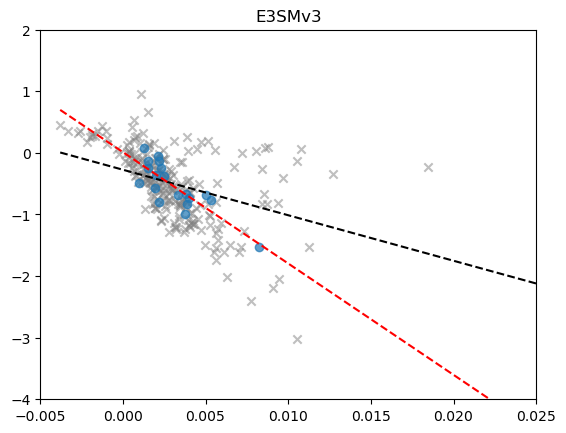

GA7.1: r2 = 0.865


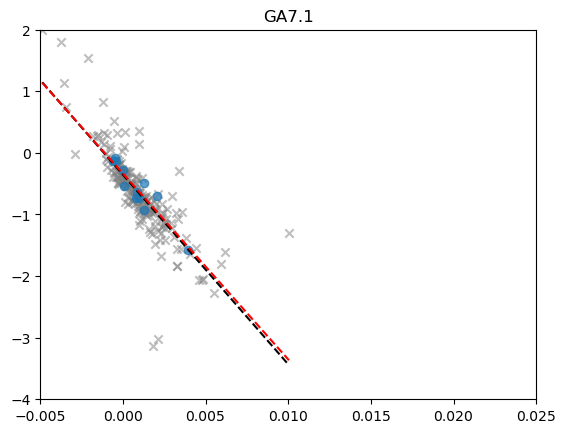

CAM6: r2 = 0.451


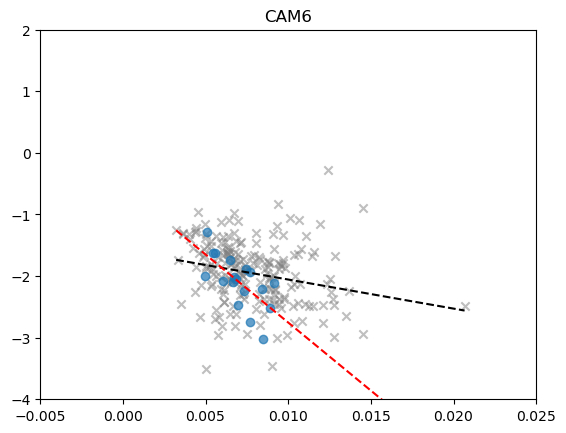

ECHAM6-HAM: r2 = 0.750


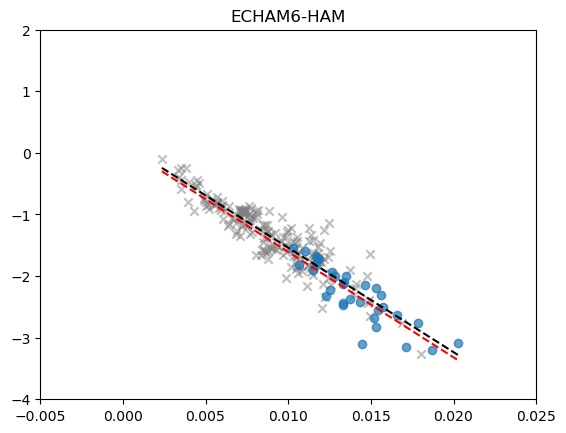

In [15]:
for ppe, ds in ds_dict.items():
    if ppe == "CAM6" or ppe == "E3SMv3":
        degree = 1
    else:
        degree = 1
        
        
    with open(pickle_path + f"{ppe}_constrained_members_dict_error_tol_0.05.pickle", "rb") as handle:
        err05_dict = pickle.load(handle)
        
    dadlwp_meet = err05_dict["dadlwp"]["match"]
    lwp_meet = err05_dict["LWP_pd"]["match"]
    dnd_meet = err05_dict["delta_Nd_pipd"]["match"]

    ensn_constr_all = [x for x in dnd_meet if (x in dadlwp_meet and x in lwp_meet)]
    ensn_cut = [x for x in ds.member.values if x not in ensn_constr_all]
    
    ds_constr = ds.sel(member=ensn_constr_all)
    xc = ds_constr["delta_LWP"]/1000. * ds_constr["dadlwp"]
    yc = ds_constr["ERFaci"]
    x = ds["delta_LWP"]/1000. * ds["dadlwp"]
    y = ds["ERFaci"]
    coeffs_erf_dlwp = mpc.get_fit_line(ppe, xc, yc, degree=degree, save=True, varname="ERFaci_dLWPxdadlwp_constr_Ndpipd", 
                                         out_path=out_path, print_r2=True)
    coeffs_erf_dlwp_prior = mpc.get_fit_line(ppe, x, y, degree=degree, save=True, varname="ERFaci_dLWPxdadlwp_prior_Ndpipd", 
                                         out_path=out_path)

    xnc = ds["delta_LWP"].sel(member=ensn_cut)/1000. * ds["dadlwp"].sel(member=ensn_cut)
    ync = ds["ERFaci"].sel(member=ensn_cut)

    fig, ax = plt.subplots()
    ax.scatter(xnc, ync, color="grey", marker="x", alpha=0.5)
    ax.scatter(xc, yc, alpha=0.7)
    xspan = np.linspace(x.min(), x.max(), 40)
    if len(coeffs_erf_dlwp) == 2:
        yfit = mpc.linear(xspan, coeffs_erf_dlwp)
    else:
        yfit = mpc.quadratic(xspan, coeffs_erf_dlwp)
    if len(coeffs_erf_dlwp_prior) == 2:
        yfit_prior = mpc.linear(xspan, coeffs_erf_dlwp_prior)
    else:
        yfit_prior = mpc.quadratic(xspan, coeffs_erf_dlwp_prior)
        
    ax.plot(xspan, yfit_prior, color="k", linestyle="--")
    ax.plot(xspan, yfit, color="r", linestyle="--")
    ax.set_title(ppe)
    ax.set_xlim(-0.005, 0.025)
    ax.set_ylim(-4, 2)
    plt.show()
